In [1]:
import pickle
import os
from glob import glob
import random
import warnings
import matplotlib.pyplot as plt
from matplotlib import rcParams
from cmcrameri import cm
import seaborn as sns
from pandas import DataFrame, read_parquet
from numpy import arange, array, isnan
import statsmodels.api as sm
from IPython.display import display
from datetime import datetime

import func_gev as gev
import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style('whitegrid')
%matplotlib inline

fs = 12

# Settings

In [2]:
path_data = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/exploration/'

dir_results = '../output/gev_analysis/2026-03-04'
dir_data_pkl = '../output/gev_analysis/2026-03-04/data.parquet'

In [3]:
HINDCAST_START = 1960
HINDCAST_END = 2026

In [4]:
axes_color: str = '#333333'
markers_color: str = "#99E3DDFF"
colors_reg: list = ['#333333FF', '#7F6C7BFF']  

In [5]:
RETURN_PERIODS = [10, 25, 50, 100, 200]
PLOT_PERIOD_EVOLUTION = ['10-year', '50-year', '100-year']

In [6]:
z_ci = 1.645 # two-side 90% CI interval (5% each side)

In [8]:
# adding a little randomness to enhance trust the model works as robust as possible cross locations..
start_location = 0 #random.choice(arange(0, 9579))
end_location = 200#start_location+10

print(f'analyse a subsample of location {start_location}–{end_location}')

analyse a subsample of location 0–200


# Import Data

In [9]:
ls_files = [file for file in glob(path_data + '*.nc')]
ls_files

['../input/Annual_max_DCPP_20260112/Annual_max_MIROC6.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_MPI-ESM1-2-HR.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_HadGEM3-GC31-MM.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_MRI-ESM2-0.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_BCC-CSM2-MR.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_CMCC-CM2-SR5.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_CanESM5.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_NorCPM1.nc']

### models

In [10]:
dic_data_per_model = dbf.import_all_models(ls_files)

### data for location trend regression

In [11]:
[
    results_annual_stat_all, results_nonstat_all, location_geo_info, location_point_info
    ] = ut.import_info_for_regression(dir_results)

loading ../output/gev_analysis/2026-03-04/stationary_per_year.pkl
loading ../output/gev_analysis/2026-03-04/nonstationary.pkl
loading ../output/gev_analysis/2026-03-04/LatLon.pkl
loading ../output/gev_analysis/2026-03-04/location_info.pkl


# Data Processing...

### BiasCorrection,...

In [12]:
dic_data_per_model, combined, notes_overview = dbf.prepare_combined_data(ls_files, dic_data_per_model)

In [13]:
dic_data_per_location = dbf.extract_location_data(combined, HINDCAST_START, HINDCAST_END)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19364158174071416s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.15845108032226562s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 188 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 248 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 316 tasks      | elaps

# VISUALS

### Plot Map of Missing Data

In [ ]:
n_obs_per_location = dbf.get_number_of_observations_per_site(dic_data_per_location)
n_obs_per_location

In [ ]:
df_missing_location, df_valid, fig_map = dbf.create_summary_location_w_missing_data(
    dic_data_per_model=dic_data_per_model, combined=combined, n_obs_per_location=n_obs_per_location, 
    dir_export=None
    )

In [ ]:
display(fig_map)

### Plot Map of Trends of Non-Stationary and Annual Stationary Approach

two-sided 90% CI -> z = 1.645

In [ ]:
results_annual_stat_all[0]

{'mu0': np.float64(0.12599293044945292),
 'mu1': np.float64(-0.001461973580379779),
 'mu0_se': np.float64(0.00048139549385295535),
 'mu1_se': np.float64(0.00048139549385295497),
 'years_mean': np.float64(1993.5),
 'years_std': np.float64(19.05037182489273)}

In [54]:
dic_mu_astat = dict()

for loc_id in results_annual_stat_all.keys():
    para_astat = results_annual_stat_all[loc_id]['mu_trend']
    
    dic_mu_astat[loc_id] = (para_astat['mu0'], para_astat['mu1_se'], para_astat['mu1'], para_astat['mu0_se'])
    
df_mu_astat = DataFrame(dic_mu_astat, index=['mu0_mm', 'mu0_std_mm', 'mu1_mm/yr', 'mu1_std_mm/yr']).T*1000

In [16]:
dic_mu = dict()

for loc_id in results_nonstat_all.keys():
    mu0, mu1, sigma, xi = results_nonstat_all[loc_id]['params_hat']
    mu0_std, mu1_std, sigma_std, xi_std = results_nonstat_all[loc_id]['params_std']
    
    dic_mu[loc_id] = (mu0, mu0_std, mu1, mu1_std)
    
df_mu_ns = DataFrame(dic_mu, index=['mu0_mm', 'mu0_std_mm', 'mu1_mm/yr', 'mu1_std_mm/yr']).T*1000

In [17]:
ci_mu1 = DataFrame([
    df_mu_ns['mu1_mm/yr'] - z_ci * df_mu_ns['mu1_std_mm/yr'],
    df_mu_ns['mu1_mm/yr'] + z_ci * df_mu_ns['mu1_std_mm/yr']], index=['mu1_upper', 'mu1_lower']
).T

In [18]:
rows = []

for loc_id in location_geo_info.keys():

    lat, lon = location_geo_info[loc_id]

    mu1 = df_mu_ns.loc[loc_id, 'mu1_mm/yr']
    se_mu1 = df_mu_ns.loc[loc_id, 'mu1_std_mm/yr']

    ci_mu1_lower = ci_mu1.loc[loc_id]['mu1_lower']
    ci_mu1_upper = ci_mu1.loc[loc_id]['mu1_upper']
    significant = not (ci_mu1_lower <= 0 <= ci_mu1_upper)

    rows.append({
        "loc_id": loc_id,
        "lat": lat,
        "lon": lon,
        "mu1": mu1,
        "mu1_std": se_mu1,
        "mu1_ci_lower": ci_mu1_lower,
        "mu1_ci_upper": ci_mu1_upper,
        "significant": significant
    })

df_plot = DataFrame(rows)

In [19]:
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import matplotlib.colors as mcolors
import pydeck as pdk
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import contextily as ctx
import geopandas as gpd
from numpy import abs, nanpercentile

cmap = cm.vik

In [20]:
max_abs = nanpercentile(abs(df_plot["mu1"]), 98)
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

In [21]:
def mu1_to_color(val):
    rgba = cmap(norm(val))
    return [int(255*c) for c in rgba[:3]]  # drop alpha

df_plot["color"] = df_plot["mu1"].apply(mu1_to_color)

In [22]:
max_se = nanpercentile(df_plot["mu1_std"], 98)

def se_to_alpha(se):
    # higher uncertainty → more transparent
    norm_se = min(se / max_se, 1)
    alpha = int(255 * (1 - norm_se))
    return max(alpha, 40)  # prevent fully invisible

df_plot["alpha"] = df_plot["mu1_std"].apply(se_to_alpha)

In [23]:
df_plot["color_rgba"] = df_plot.apply(
    lambda row: row["color"] + [row["alpha"]],
    axis=1
)

In [24]:
min_r = 5000
max_r = 40000

df_plot["radius"] = min_r + (
    (df_plot["mu1_std"] / max_se).clip(0, 1) * (max_r - min_r)
)

In [30]:
df_plot.alpha.unique()

array([148, 128, 149, 129, 127, 131, 132, 133, 130, 136, 125, 147, 145,
       126, 146, 135, 134, 139, 140, 144, 142, 143, 150, 151, 152,  40,
        71,  64,  93,  98,  75,  97, 138, 103, 137, 102, 107, 108, 106,
       105, 101, 100,  86,  87, 119])

In [29]:
df_plot["mu1_str"] = df_plot["mu1"].map("{:.4f}".format)
df_plot["mu1_std_str"] = df_plot["mu1_std"].map("{:.4f}".format)
df_plot["mu1_ci_lower_str"] = df_plot["mu1_ci_lower"].map("{:.4f}".format)
df_plot["mu1_ci_upper_str"] = df_plot["mu1_ci_upper"].map("{:.4f}".format)

layer = pdk.Layer(
    "ScatterplotLayer",
    data=df_plot,
    get_position='[lon, lat]',
    get_fill_color="color_rgba",
    get_radius=5000,  # fixed if using alpha
    pickable=True,
)

view_state = pdk.ViewState(
    latitude=df_plot["lat"].mean(),
    longitude=df_plot["lon"].mean(),
    zoom=5,
)

deck = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state,
    map_style="https://tiles.openfreemap.org/styles/positron",
    tooltip={
        "html": """
            <b>Location</b><br>
            Lat: {lat}<br>
            Lon: {lon}<br>
            μ₁: {mu1_str}<br>
            SE: {mu1_std_str}<br>
            CI_lower: {mu1_ci_lower_str}<br>
            CI_upper: {mu1_ci_upper_str}<br>
        """,
        "style": {"backgroundColor": "steelblue", "color": "white", "padding": "8px"}
    }
    )


today_ = str(datetime.today().date().isoformat()) 

output_path = f"../output/gev_analysis/{today_}/figures/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

print('map stored as %s', output_path + "/Map_trend_location_including_ci.html")
deck.to_html(output_path + "/Map_trend_location_including_ci.html")


map stored as %s ../output/gev_analysis/2026-03-04/figures//Map_trend_location_including_ci.html


In [31]:
max_se = nanpercentile(df_plot["mu1_std"], 98)
df_plot['alpha'] = (1 - (df_plot['mu1_std']/max_se)).clip(0.2, 1.0)  # min alpha 0.2

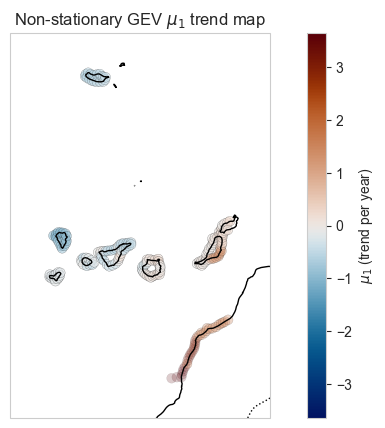

In [35]:
fig = plt.figure(figsize=(12,5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent(
    [df_plot['lon'].min()-1, df_plot['lon'].max()+1, df_plot['lat'].min()-1, df_plot['lat'].max()+1]
    )

sc = ax.scatter(
    df_plot['lon'], df_plot['lat'],
    c=df_plot['mu1'],
    cmap=cmap,
    norm=norm,
    s=50,
    alpha=df_plot['alpha'],
    edgecolor='k',
    linewidth=0.2,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('$μ_1$ (trend per year)')
plt.title('Non-stationary GEV $μ_1$ trend map')
plt.show()

In [36]:
gdf = gpd.GeoDataFrame(
    df_plot,
    geometry=gpd.points_from_xy(df_plot['lon'], df_plot['lat']),
    crs="EPSG:4326"  # WGS84
)

In [37]:
gdf_web = gdf.to_crs(epsg=3857) 

In [38]:
max_abs = nanpercentile(abs(gdf['mu1']), 98)
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

max_se = nanpercentile(gdf['mu1_std'], 98)
gdf_web['alpha'] = (1 - (gdf_web['mu1_std']/max_se)).clip(0.2, 1.0)
gdf_web['size'] = 20 + (1 - (gdf_web['mu1_std']/max_se)).clip(0,1) * 180

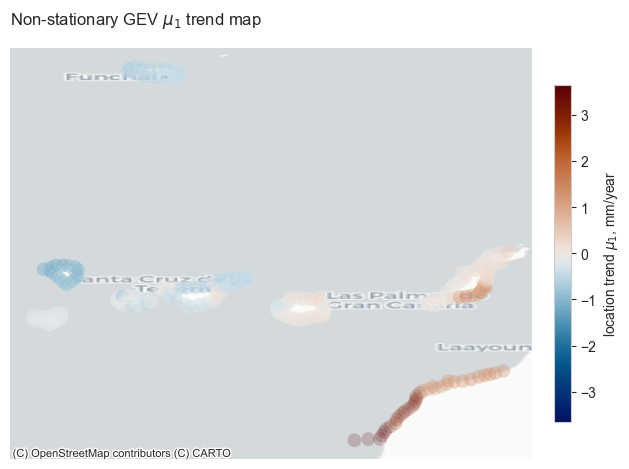

In [ ]:
fig, ax = plt.subplots()#figsize=(12,5))
sc = ax.scatter(
    gdf_web.geometry.x, gdf_web.geometry.y,
    c=gdf_web['mu1'], cmap=cmap, norm=norm, s=100,#gdf_web['size'],
    alpha=gdf_web['alpha'], edgecolor='white', linewidth=0.15
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=6)

ax.set_axis_off()  
plt.title("Non-stationary GEV $μ_1$ trend map", loc='left')
cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("location trend $μ_1$, mm/year")

plt.tight_layout()
plt.show()